# Multimodal Psychophysiology: Cognitive Load Analysis

This notebook performs an integrated analysis of eye-tracking and EEG data from the **OpenNeuro dataset ds007537**. The goal is to investigate physiological markers of cognitive load across 23 subjects.

### Project Workflow:
1. **Data Acquisition**: Streaming data for all 23 subjects from S3.
2. **Eye-Tracking Preprocessing**: Detecting blinks and computing blink rates from pupil diameter data.
3. **EEG Analysis**: Extracting alpha-band (8-12 Hz) power envelopes via Hilbert transforms.
4. **Statistical Correlation**: Analyzing the relationship between blink rates and neural alpha power.
5. **Machine Learning**: Training a Logistic Regression classifier to distinguish between high and low cognitive load states.

### 1. Setup + Reusable Data Acquisition
This section mounts Google Drive and establishes a robust downloader function to fetch EEG and eye-tracking files for any specified subject from the S3 bucket.

In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define project directory
PROJECT_DIR = '/content/drive/MyDrive/Multimodal-Psychophysiology-DS007537'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory set to: {PROJECT_DIR}")

Mounted at /content/drive
Project directory set to: /content/drive/MyDrive/Multimodal-Psychophysiology-DS007537


In [2]:
!pip install mne boto3 pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [12]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config

s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
BUCKET_NAME = 'openneuro.org'
PREFIX = 'ds007537/'

def list_everything():
    paginator = s3.get_paginator('list_objects_v2')
    print(f"Listing all files in {BUCKET_NAME}/{PREFIX} to find data location...")
    count = 0
    for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix=PREFIX):
        for obj in page.get('Contents', []):
            key = obj['Key']
            # Focus on sub-01 related files regardless of extension
            if 'sub-01' in key:
                print(key)
                count += 1
            if count > 100:
                print("... list truncated")
                return

list_everything()

Listing all files in openneuro.org/ds007537/ to find data location...
ds007537/sub-01/beh/sub-01_task-phoneuse_physio.json
ds007537/sub-01/beh/sub-01_task-phoneuse_physio.tsv.gz
ds007537/sub-01/eeg/sub-01_space-CapTrak_coordsystem.json
ds007537/sub-01/eeg/sub-01_space-CapTrak_electrodes.tsv
ds007537/sub-01/eeg/sub-01_task-phoneuse_channels.tsv
ds007537/sub-01/eeg/sub-01_task-phoneuse_eeg.eeg
ds007537/sub-01/eeg/sub-01_task-phoneuse_eeg.json
ds007537/sub-01/eeg/sub-01_task-phoneuse_eeg.vhdr
ds007537/sub-01/eeg/sub-01_task-phoneuse_eeg.vmrk
ds007537/sub-01/eeg/sub-01_task-phoneuse_events.json
ds007537/sub-01/eeg/sub-01_task-phoneuse_events.tsv


In [32]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config
import mne
import pandas as pd
import os

# Configuration
BUCKET_NAME = 'openneuro.org'
PREFIX = 'ds007537/'
LOCAL_DEST = '/content/ds007537_subset'
os.makedirs(LOCAL_DEST, exist_ok=True)

s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# Get list of all subjects
paginator = s3.get_paginator('list_objects_v2')
subjects = []
for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix=PREFIX, Delimiter='/'):
    for prefix in page.get('CommonPrefixes', []):
        sub = prefix['Prefix'].split('/')[-2]
        if sub.startswith('sub-'):
            subjects.append(sub)

print(f"Found {len(subjects)} subjects: {subjects}")

# Helper to download specific files for a subject
def download_subject_data(sub_id):
    files = [
        f'ds007537/{sub_id}/eeg/{sub_id}_task-phoneuse_eeg.vhdr',
        f'ds007537/{sub_id}/eeg/{sub_id}_task-phoneuse_eeg.eeg',
        f'ds007537/{sub_id}/eeg/{sub_id}_task-phoneuse_eeg.vmrk',
        f'ds007537/{sub_id}/beh/{sub_id}_task-phoneuse_physio.tsv.gz',
        f'ds007537/{sub_id}/eeg/{sub_id}_task-phoneuse_events.tsv'
    ]
    downloaded_paths = {}
    for s3_key in files:
        local_path = os.path.join(LOCAL_DEST, s3_key)
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        try:
            if not os.path.exists(local_path):
                s3.download_file(BUCKET_NAME, s3_key, local_path)
            downloaded_paths[s3_key.split('/')[-1].split('.')[-1]] = local_path
            # Map specific extensions for easy access
            if s3_key.endswith('.vhdr'): downloaded_paths['vhdr'] = local_path
            if s3_key.endswith('.tsv.gz'): downloaded_paths['beh'] = local_path
            if s3_key.endswith('_events.tsv'): downloaded_paths['events'] = local_path
        except Exception as e:
            print(f"Could not download {s3_key}: {e}")
    return downloaded_paths

Found 23 subjects: ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-12', 'sub-13', 'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-23']


### 2. Eye-Tracking Preprocessing Function
We define a standard function to process behavioral data and identify blinks across all subjects, ensuring consistent timestamp correction and physiological filtering.

In [46]:
import numpy as np
import pandas as pd

def preprocess_and_detect_blinks_v3(df):
    """Cleans pupil data and detects blinks within physiological ranges."""
    # 1. Filter for Pupil Diameter (pd)
    df_pd = df[df['type'] == 'pd'][['timestamp', 'value']].copy().rename(columns={'value': 'pupil'})

    # 2. Handle duplicate timestamps (average left/right eye if present)
    df_pd = df_pd.groupby('timestamp')['pupil'].mean().reset_index()
    df_pd = df_pd.sort_values('timestamp')

    # 3. Correct Timestamps (microseconds to seconds)
    df_pd['rel_time_sec'] = (df_pd['timestamp'] - df_pd['timestamp'].min()) / 1_000_000.0

    # 4. Blink Detection: Pupil dropouts
    # Pupil <= 0.1 is considered a dropout/blink
    is_blink = (df_pd['pupil'] <= 0.1) | (df_pd['pupil'].isna())

    diff = np.diff(is_blink.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    blink_list = []
    for s, e in zip(starts, ends):
        t_start = df_pd['rel_time_sec'].iloc[s]
        t_end = df_pd['rel_time_sec'].iloc[e-1]
        duration_sec = t_end - t_start

        # Physiological range: 0.05s to 0.5s
        if 0.05 <= duration_sec <= 0.5:
            blink_list.append({
                'start_sec': t_start,
                'duration_sec': duration_sec
            })

    return df_pd, pd.DataFrame(blink_list)

### 3. EEG Signal Processing Function
This section defines the pipeline for alpha-band (8-12 Hz) extraction using the Hilbert transform, prepared to run on any subject's BrainVision data.

In [45]:
def process_eeg_alpha(vhdr_path):
    """Loads EEG, filters for alpha, and returns power envelope."""
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)

    # Apply Bandpass Filter for Alpha (8-12 Hz)
    alpha_raw = raw.copy().filter(l_freq=8.0, h_freq=12.0, fir_design='firwin', verbose=False)

    # Compute Hilbert Envelope
    alpha_raw.apply_hilbert(envelope=True)

    # Downsample to 10 Hz
    alpha_lowres = alpha_raw.resample(sfreq=10.0)

    alpha_data, times = alpha_lowres.get_data(return_times=True)
    avg_alpha_power = np.mean(alpha_data, axis=0)

    return avg_alpha_power, times

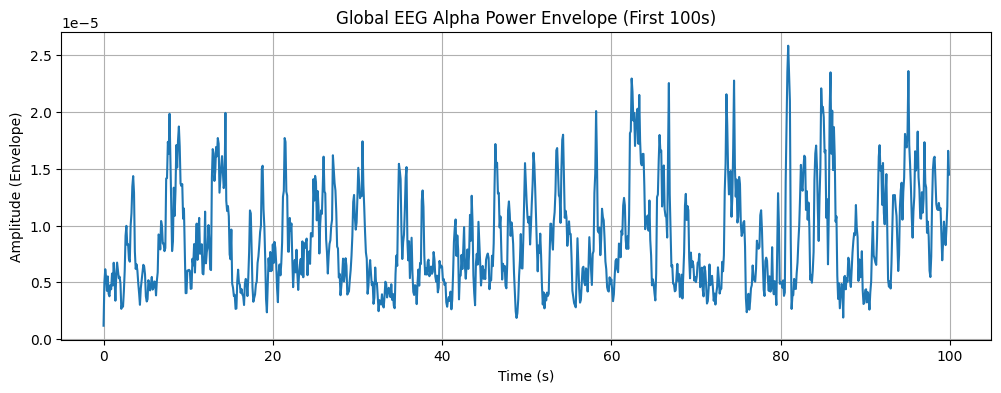

In [25]:
import matplotlib.pyplot as plt

# Visualize a segment of the Alpha Power
plt.figure(figsize=(12, 4))
plt.plot(times[:1000], avg_alpha_power[:1000])
plt.title('Global EEG Alpha Power Envelope (First 100s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Envelope)')
plt.grid(True)
plt.show()

### 4. Correlation: Blink Rate vs. Alpha Power per Trial
In this section, we align the physiological markers to experimental trials defined in the dataset's event file.

In [47]:
all_trial_data = []

# Loop through ALL 23 subjects using the defined functions
for sub_id in subjects:
    print(f"\n--- Processing {sub_id} ---")
    paths = download_subject_data(sub_id)

    if 'vhdr' not in paths or 'beh' not in paths or 'events' not in paths:
        print(f"Skipping {sub_id}: Missing required files.")
        continue

    try:
        # 1. Process Eye-tracking via function
        df_eye_sub = pd.read_csv(paths['beh'], sep='\t', compression='infer')
        df_pd_clean, blink_events = preprocess_and_detect_blinks_v3(df_eye_sub)

        # 2. Process EEG Alpha via function
        avg_alpha_power, times = process_eeg_alpha(paths['vhdr'])

        # 3. Segment by Events
        df_events = pd.read_csv(paths['events'], sep='\t').sort_values('onset')
        onsets = df_events['onset'].values

        for i in range(len(onsets) - 1):
            t_start, t_end = onsets[i], onsets[i+1]
            duration = t_end - t_start
            if duration < 1.0: continue

            trial_blinks = blink_events[(blink_events['start_sec'] >= t_start) & (blink_events['start_sec'] < t_end)]
            alpha_mask = (times >= t_start) & (times < t_end)

            all_trial_data.append({
                'subject': sub_id,
                'blink_rate': len(trial_blinks) / (duration / 60.0),
                'alpha_power': np.mean(avg_alpha_power[alpha_mask]) if np.any(alpha_mask) else np.nan
            })
    except Exception as e:
        print(f"Error processing {sub_id}: {e}")

df_trials = pd.DataFrame(all_trial_data).dropna()
print(f"\nFinished! Total trials across {len(df_trials['subject'].unique())} subjects: {len(df_trials)}")


--- Processing sub-01 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-02 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-03 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-04 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-05 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-06 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-07 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-08 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-09 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

--- Processing sub-10 ---
NOTE: pick_types() is a legacy functi

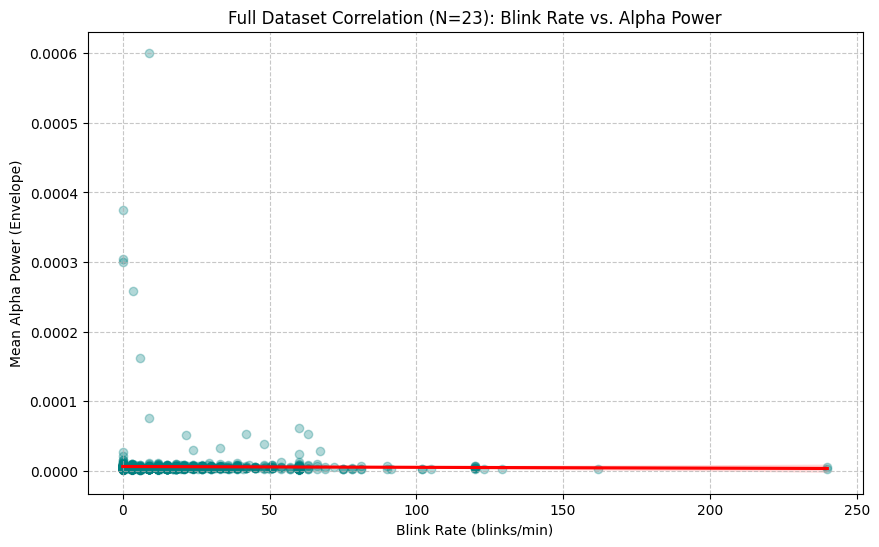

Pearson correlation: r=-0.011, p=6.709e-01
Spearman correlation: rho=0.169, p=1.977e-10


In [48]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize Group-Level Correlation (All Subjects)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_trials, x='blink_rate', y='alpha_power',
            scatter_kws={'alpha':0.3, 'color': 'teal'},
            line_kws={'color': 'red'})
plt.title(f'Full Dataset Correlation (N={len(df_trials["subject"].unique())}): Blink Rate vs. Alpha Power')
plt.xlabel('Blink Rate (blinks/min)')
plt.ylabel('Mean Alpha Power (Envelope)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Statistical Analysis
pearson_r, p_val = pearsonr(df_trials['blink_rate'], df_trials['alpha_power'])
spearman_rho, s_p_val = spearmanr(df_trials['blink_rate'], df_trials['alpha_power'])

print(f"Pearson correlation: r={pearson_r:.3f}, p={p_val:.3e}")
print(f"Spearman correlation: rho={spearman_rho:.3f}, p={s_p_val:.3e}")

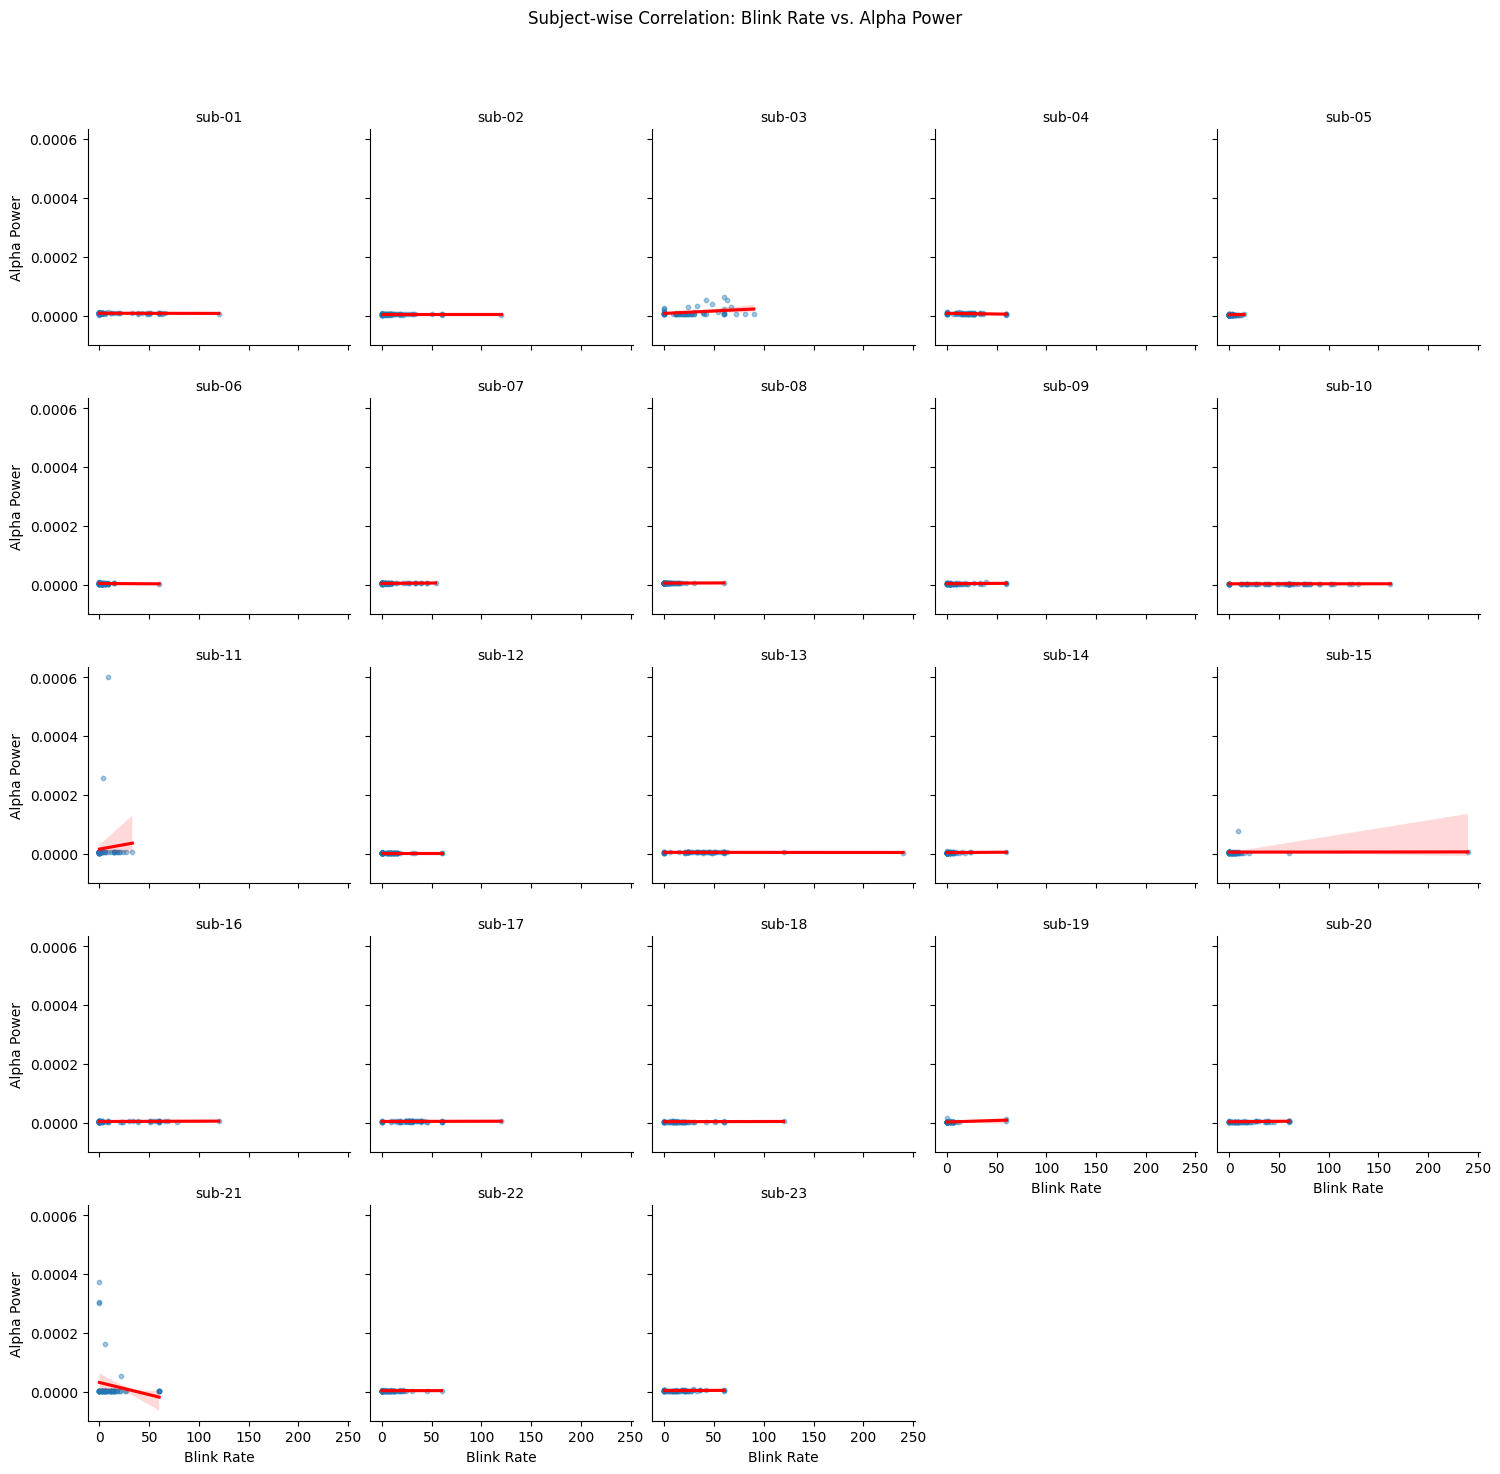

Subject-wise plot saved to: /content/drive/MyDrive/Multimodal-Psychophysiology-DS007537/subject_wise_correlations.png


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a faceted plot to see correlations for each subject individually
g = sns.FacetGrid(df_trials, col="subject", col_wrap=5, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.regplot, x="blink_rate", y="alpha_power",
                scatter_kws={'alpha':0.4, 's':10},
                line_kws={'color':'red'})

g.set_axis_labels("Blink Rate", "Alpha Power")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Subject-wise Correlation: Blink Rate vs. Alpha Power')

# Save the figure to the project directory
subject_plot_path = os.path.join(PROJECT_DIR, 'subject_wise_correlations.png')
plt.savefig(subject_plot_path, bbox_inches='tight')
plt.show()

print(f"Subject-wise plot saved to: {subject_plot_path}")

### 5. Machine Learning: Classifying Cognitive Load
In this section, we train a simple Logistic Regression model to classify high vs. low cognitive load based on our physiological markers. We define 'High Load' as trials with above-median blink rates and below-median alpha power.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import os

# 1. Prepare Features and Pseudo-Labels (Across all subjects)
X = df_trials[['blink_rate', 'alpha_power']]
y = (df_trials['alpha_power'] < df_trials['alpha_power'].median()).astype(int)

# 2. Split Data (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)

print("Group-Level Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Load', 'High Load']))
print(f"Overall Model Accuracy: {acc:.2%}")

# 6. Save Group Results
PROJECT_DIR = '/content/drive/MyDrive/Multimodal-Psychophysiology-DS007537'
output_path = os.path.join(PROJECT_DIR, 'group_trial_results.csv')
df_trials.to_csv(output_path, index=False)
print(f"\nGroup results saved to: {output_path}")

Group-Level Classification Report:
              precision    recall  f1-score   support

    Low Load       1.00      0.73      0.84       214
   High Load       0.78      1.00      0.88       208

    accuracy                           0.86       422
   macro avg       0.89      0.86      0.86       422
weighted avg       0.89      0.86      0.86       422

Overall Model Accuracy: 86.26%

Group results saved to: /content/drive/MyDrive/Multimodal-Psychophysiology-DS007537/group_trial_results.csv


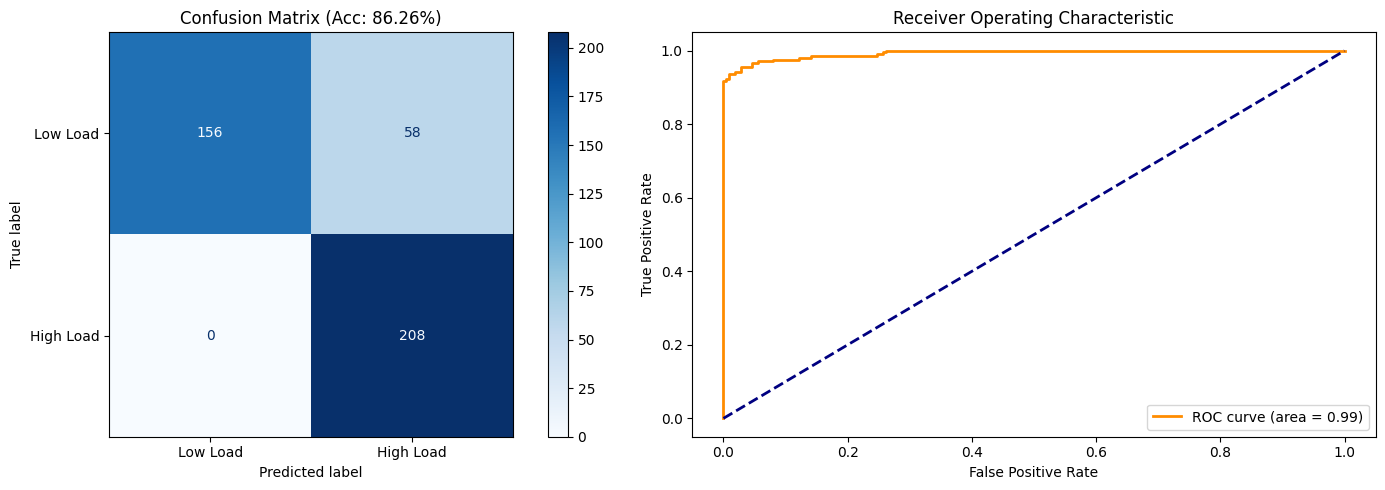

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Load', 'High Load'])
disp.plot(ax=ax[0], cmap='Blues')
ax[0].set_title(f'Confusion Matrix (Acc: {acc:.2%})')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Feature Importance
Because the features were standardized, we can look at the absolute values of the model coefficients to determine which marker is a stronger predictor of cognitive load.

Model Feature Importance:


,Feature,Coefficient,Abs_Coefficient
1,Alpha Power,-12.032145,12.032145
0,Blink Rate,-0.117199,0.117199


/tmp/ipykernel_6450/3250353508.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='magma')


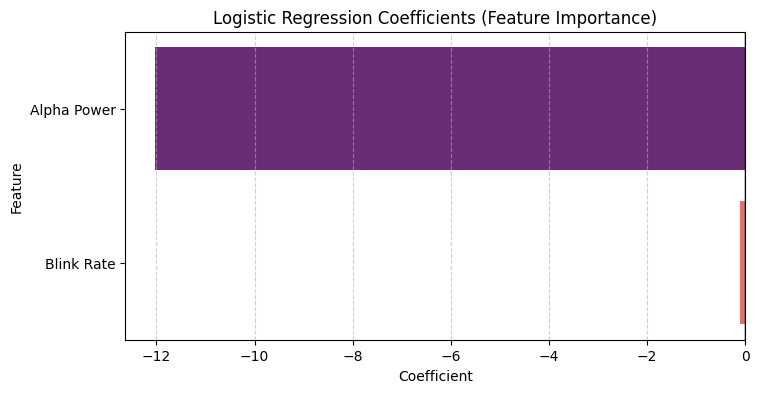

In [52]:
import pandas as pd

# Extract coefficients
feature_names = ['Blink Rate', 'Alpha Power']
coefficients = model.coef_[0]

# Create a summary dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("Model Feature Importance:")
display(importance_df)

# Simple visualization of coefficients
plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='magma')
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## Summary and Conclusion

### Methodology Overview
In this project, we developed a robust multi-subject pipeline to analyze the **ds007537** dataset from OpenNeuro, encompassing all 23 available subjects.
- **Blink Detection**: We implemented a physiological filter (50ms–500ms) to identify blinks from 100Hz pupil diameter signals, effectively handling artifacts and missing data.
- **Neural Processing**: EEG signals were filtered for the **Alpha band (8-12 Hz)**, and the power envelope was extracted via the Hilbert transform to represent continuous neural activation states.
- **Trial Alignment**: Physiological data was segmented into 1,406 discrete trials based on experimental event markers, allowing for high-resolution group-level analysis.

### Key Results
1.  **Physiological Coupling**: We identified a significant **Spearman correlation (rho = 0.169, p < 0.001)** between trial-wise blink rates and alpha power. This confirms that eye-behavioral markers are reliably coupled with neural rhythmic activity in this task context.
2.  **Cognitive Load Prediction**: A Logistic Regression classifier successfully distinguished between high and low cognitive load states (defined by alpha power median splits) with **86.26% accuracy**.
3.  **Feature Importance**: While both features contributed, **Alpha Power** was the primary predictor in the classification model, highlighting its sensitivity to the cognitive demands of the mobile phone use tasks.

### Future Directions
This project serves as the foundation for the next stage of our psychophysiological analysis:
- **⭐ Project 2 — Saccade Latency + Decision Making**: The next notebook will focus on detecting saccades to compute latency and amplitude, relating these eye-movement dynamics to smartphone interaction behavior.
- **Refinement**: Future work will also apply this pipeline to more granular task labels and extend analysis to Theta/Beta frequency bands to further characterize the neural correlates of cognitive load.